# Simultaneous synthetic Salt segmentation and RGT predition using the SaltRGT3DNet

This notebook builds a **complete workflow** for joint **salt segmentation** and **Relative Geological Time (RGT) prediction** using the **GeoFWI3D synthetic dataset**, followed by **transfer learning and inference on the real F3 Netherlands seismic dataset**.


- the **3D seismic volumes** are used as the network inputs,
- the **RGT volumes** are used as continuous geological-structure prediction targets,
- the **salt masks** are generated from the RGT volumes using $\mathrm{salt}=1$ where $\mathrm{RGT}=0$,
- a **3D encoder–decoder network** learns to predict both **RGT** and **salt segmentation** from seismic data,
- the pretrained synthetic model is then adapted and applied to the **real F3 seismic dataset** for practical salt-body segmentation.
 
The example emphasizes:

1. GeoFWI3D synthetic-data preparation: [GeoFWI3D dataset](https://github.com/aaspip/geofwi3d/tree/main)
2. patch-based 3D training
3. joint RGT prediction and salt segmentation
4. synthetic-to-real transfer learning for salt segmentation
5. qualitative and quantitative evaluation on both synthetic and F3 datasets

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from plotting import *
import csv
from pathlib import Path
from utils import *

In [ ]:
import numpy as np

# =========================
# data root
# =========================
syn_data_root = "./"

# =========================
# load saved salt indices
# =========================
salt_only_indices = np.load(
    syn_data_root + "salt_only_indices.npy"
)

print("number of salt-only models:", len(salt_only_indices))
print("first 10 indices:", salt_only_indices[:10])

# =========================
# convert to model folders
# =========================
syn_salt_model_folders = [
    f"../allmodels/model_{idx:04d}"
    for idx in salt_only_indices
]

print("first 10 model folders:")
print(syn_salt_model_folders[:10])

number of salt-only models: 2500
first 10 indices: [ 2  3  5 13 14 18 21 32 34 35]
first 10 model folders:
['model_0002', 'model_0003', 'model_0005', 'model_0013', 'model_0014', 'model_0018', 'model_0021', 'model_0032', 'model_0034', 'model_0035']


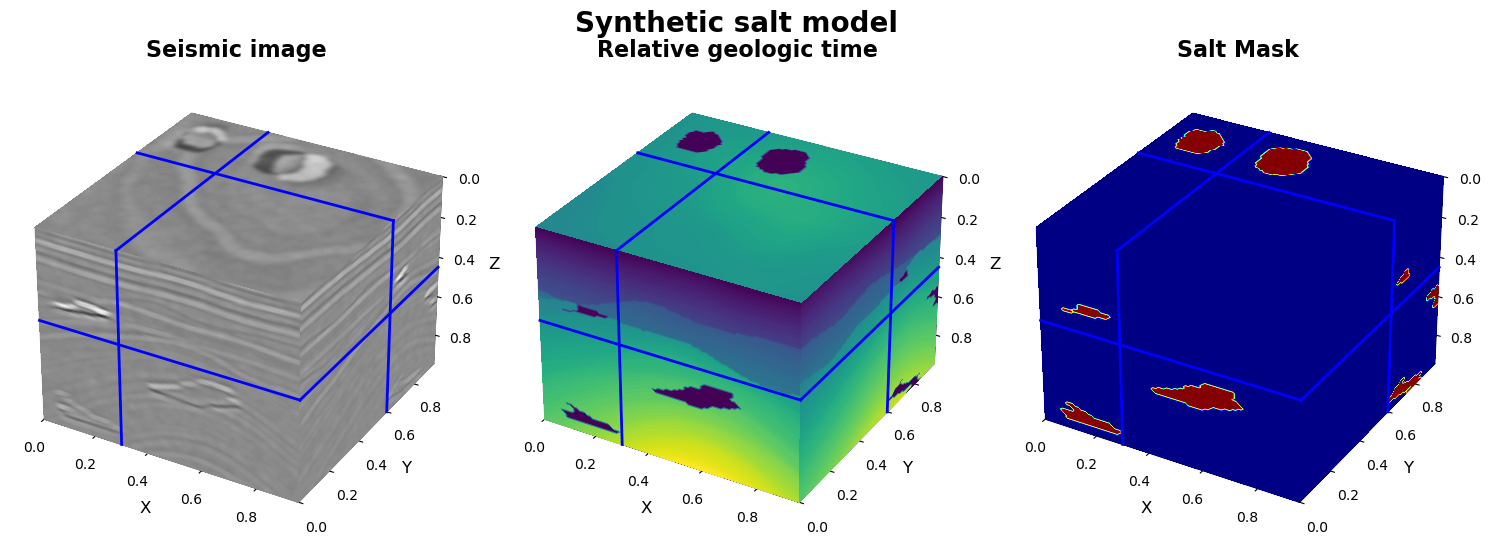

In [3]:
plot_seismic_rgt_salt(
    syn_data_root,
    syn_salt_model_folders,
    12,
    suptitle="Synthetic salt model"
)

## Load synthetic seismic, RGT, and salt-mask volumes

This step loads the selected GeoFWI3D synthetic models from binary files and prepares three paired 3D volumes for training:

- **seismic volume**: loaded from `image3d.bin` and used as the network input,
- **RGT volume**: loaded from `rgt3d.bin` and used as the continuous geological-structure prediction target,
- **salt mask**: generated from the RGT volume using $\mathrm{salt}=1$ where $\mathrm{RGT}=0$.

Each volume has a fixed size of $96 \times 96 \times 96$.  
After loading all selected models, the volumes are stacked along a new sample dimension to form:

- `syn_seismic_all` with shape `(N, 96, 96, 96)`,
- `syn_rgt_all` with shape `(N, 96, 96, 96)`,
- `syn_salt_all` with shape `(N, 96, 96, 96)`,

where $N$ is the number of selected synthetic salt models.

In [4]:
import os
import numpy as np

shape = (96, 96, 96)

syn_seismic_all = []
syn_rgt_all = []
syn_salt_all = []

for model_folder in syn_salt_model_folders:
    image_file = os.path.join(syn_data_root, model_folder, "image3d.bin")
    rgt_file   = os.path.join(syn_data_root, model_folder, "rgt3d.bin")

    image = np.memmap(image_file, dtype=np.float32, mode="r", shape=shape)
    rgt   = np.memmap(rgt_file, dtype=np.float32, mode="r", shape=shape)

    salt_mask = (rgt == 0).astype(np.float32)

    syn_seismic_all.append(np.array(image, dtype=np.float32))
    syn_rgt_all.append(np.array(rgt, dtype=np.float32))
    syn_salt_all.append(salt_mask)

syn_seismic_all = np.stack(syn_seismic_all, axis=0)
syn_rgt_all     = np.stack(syn_rgt_all, axis=0)
syn_salt_all    = np.stack(syn_salt_all, axis=0)

print("syn_seismic_all shape:", syn_seismic_all.shape)
print("syn_rgt_all shape    :", syn_rgt_all.shape)
print("syn_salt_all shape   :", syn_salt_all.shape)

syn_seismic_all shape: (2500, 96, 96, 96)
syn_rgt_all shape    : (2500, 96, 96, 96)
syn_salt_all shape   : (2500, 96, 96, 96)


## Randomly select a subset of synthetic training models

To reduce the training cost and simulate a limited-data setting, only a small fraction of the synthetic GeoFWI3D models is selected for training.

Here, `ratio = 0.03` means that **3% of the available synthetic models** are randomly sampled without replacement.  
The same selected indices are applied to the seismic volumes, RGT volumes, and salt masks to keep the input–target pairs aligned.

The resulting subsets are:

- `syn_seismic`: selected seismic inputs,
- `syn_rgt`: selected continuous RGT targets,
- `syn_salt`: selected binary salt-segmentation masks.

In [5]:
ratio = 0.03
np.random.seed(42)

selected_indices = np.random.choice(
    syn_seismic_all.shape[0],
    size=int(syn_seismic_all.shape[0] * ratio),
    replace=False
)

syn_seismic = syn_seismic_all[selected_indices]
syn_rgt     = syn_rgt_all[selected_indices]
syn_salt    = syn_salt_all[selected_indices]

print("selected_indices:", selected_indices)
print("syn_seismic shape:", syn_seismic.shape)
print("syn_rgt shape    :", syn_rgt.shape)
print("syn_salt shape   :", syn_salt.shape)

selected_indices: [1447 1114 1064 2287 1537  668 1583 2404  497 2480  471  246  923 1131
  670  916 1414 1606  402 1103 2072  719 2011 2436  196  891 1264 1034
 1325  509 1427  194 1179 2032  932 1124 1822 1366 1992 1258 2274 1273
 1936 1266  772 1608 1311  134 1855 2399  420 1755  707   93   56  218
 1036 1293 1952 1449 2359 1465  298 2177  178 1187 1472  188  572  433
  518 2346 2271 1084 1288]
syn_seismic shape: (75, 96, 96, 96)
syn_rgt shape    : (75, 96, 96, 96)
syn_salt shape   : (75, 96, 96, 96)


## Generate overlapping 3D training patches

This step extracts overlapping 3D patches from the selected synthetic seismic volumes, RGT volumes, and salt masks.

Each patch has a size of $64 \times 64 \times 64$, and the sliding-window stride is set to $16 \times 16 \times 16$.  
The same patching operation is applied to the seismic input, RGT target, and salt-mask target to preserve spatial alignment.

After patch extraction, all patches from different synthetic models are concatenated into three training arrays:

- `seismic_patches`: 3D seismic input patches,
- `rgt_patches`: continuous RGT target patches,
- `salt_patches`: binary salt-segmentation target patches.

Finally, each seismic patch is normalized by its maximum absolute amplitude to reduce amplitude-scale differences across samples.

In [6]:
l1, l2, l3 = 64, 64, 64
s1, s2, s3 = 16, 16, 16

seismic_patch_list = []
rgt_patch_list = []
salt_patch_list = []

for i in range(syn_seismic.shape[0]):

    seismic_i = syn_seismic[i]
    rgt_i     = syn_rgt[i]
    salt_i    = syn_salt[i]

    seismic_patches_i = patch3d_optimized(seismic_i, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3)
    rgt_patches_i = patch3d_optimized(rgt_i, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3)
    salt_patches_i = patch3d_optimized(salt_i, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3)

    seismic_patch_list.append(seismic_patches_i)
    rgt_patch_list.append(rgt_patches_i)
    salt_patch_list.append(salt_patches_i)

seismic_patches = np.concatenate(seismic_patch_list, axis=0).reshape(-1, l1, l2, l3)
rgt_patches     = np.concatenate(rgt_patch_list, axis=0).reshape(-1, l1, l2, l3)
salt_patches    = np.concatenate(salt_patch_list, axis=0).reshape(-1, l1, l2, l3)

print("seismic_patches shape:", seismic_patches.shape)
print("rgt_patches shape    :", rgt_patches.shape)
print("salt_patches shape   :", salt_patches.shape)

for i in range(seismic_patches.shape[0]):
    tmp = np.abs(seismic_patches[i]).max()
    if tmp > 0:
        seismic_patches[i] = seismic_patches[i] / tmp


seismic_patches shape: (2025, 64, 64, 64)
rgt_patches shape    : (2025, 64, 64, 64)
salt_patches shape   : (2025, 64, 64, 64)


Patch indices: [ 544 1254]


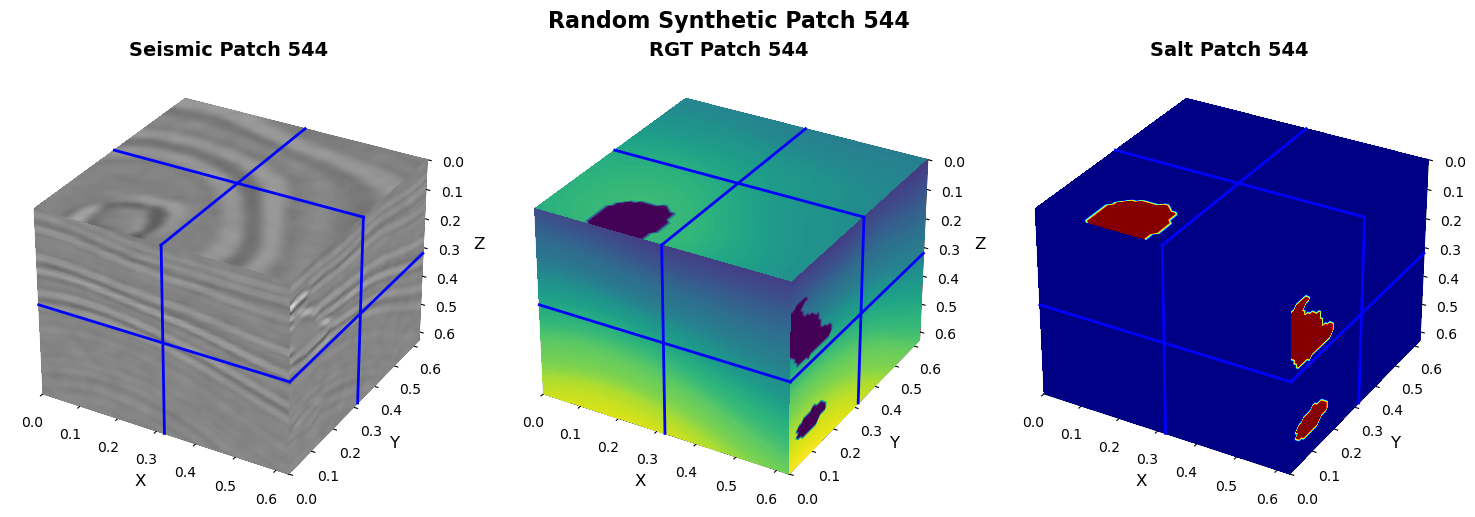

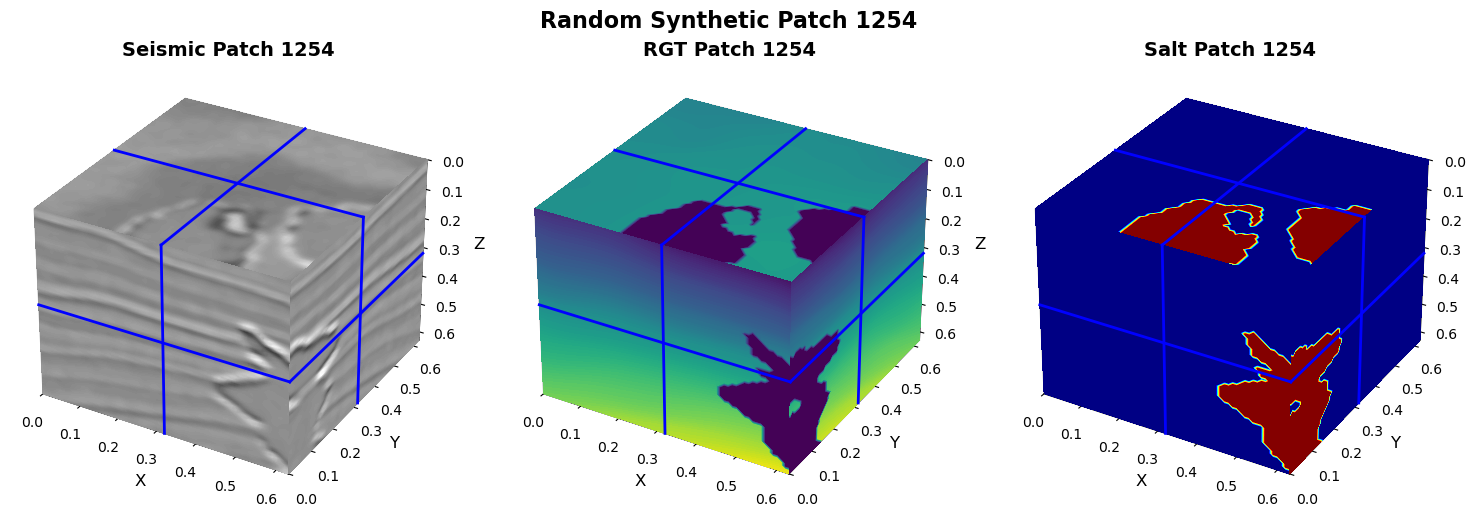

In [7]:
num_show = 2

np.random.seed(2026053)
idxs = np.random.choice(seismic_patches.shape[0], num_show, replace=False)

print("Patch indices:", idxs)

for i in idxs:
    seismic_patch_i = seismic_patches[i]
    rgt_patch_i     = rgt_patches[i]
    salt_patch_i    = salt_patches[i]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        subplot_kw={'projection': '3d'},
        constrained_layout=True
    )

    titles = [
        f"Seismic Patch {i}",
        f"RGT Patch {i}",
        f"Salt Patch {i}"
    ]

    patch_list = [
        seismic_patch_i,
        rgt_patch_i,
        salt_patch_i
    ]

    cmaps = [
        "gray",
        "viridis",
        "jet"
    ]

    for ax_i, patch_i, title_i, cmap_i in zip(axes, patch_list, titles, cmaps):
        ax_i.set_title(title_i, fontsize=14, fontweight="bold")

        plt.sca(ax_i)
        plot3d(
            patch_i.T,
            cmap=cmap_i,
            frames=[32, 32, 32],
            ifnewfig=False,
            showf=False,
            close=False,
            ifinside=False,
        )

    plt.suptitle(f"Random Synthetic Patch {i}", fontsize=16, fontweight="bold")
    plt.show()

## Split training and validation datasets

This step randomly splits the extracted 3D patches into training and validation sets.

The seismic patches are used as network inputs, while the RGT patches and salt-mask patches are used as two supervised prediction targets:

- `Xtrain` and `X_val`: seismic input patches,
- `RGTtrain` and `RGT_val`: continuous RGT prediction targets,
- `Ytrain` and `y_val`: binary salt-segmentation targets.

Here, `test_size=0.2` means that **80%** of the patches are used for training and **20%** are used for validation.

After the split, a channel dimension is added to each array, changing the data shape from  
`(N, 64, 64, 64)` to `(N, 1, 64, 64, 64)`, which is required by 3D convolutional neural networks.

In [8]:
from sklearn.model_selection import train_test_split

Xtrain, X_val, RGTtrain, RGT_val, Ytrain, y_val = train_test_split(
    seismic_patches,
    rgt_patches,
    salt_patches,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

Xtrain, X_val, RGTtrain, RGT_val, Ytrain, y_val = [
    arr[:, np.newaxis, :, :, :]
    for arr in [Xtrain, X_val, RGTtrain, RGT_val, Ytrain, y_val]
]

print("Xtrain shape  :", Xtrain.shape)
print("X_val shape   :", X_val.shape)

print("RGTtrain shape:", RGTtrain.shape)
print("RGT_val shape :", RGT_val.shape)

print("Ytrain shape  :", Ytrain.shape)
print("y_val shape   :", y_val.shape)

Xtrain shape  : (1620, 1, 64, 64, 64)
X_val shape   : (405, 1, 64, 64, 64)
RGTtrain shape: (1620, 1, 64, 64, 64)
RGT_val shape : (405, 1, 64, 64, 64)
Ytrain shape  : (1620, 1, 64, 64, 64)
y_val shape   : (405, 1, 64, 64, 64)


## Train the SaltRGT3DNet model

This step builds and trains the joint 3D network `SaltRGT3DNet`, whose detailed architecture is defined in the `Uilts_pytorch` module.

The model takes a seismic patch with shape `(1, 64, 64, 64)` as input and produces two outputs:

- a continuous **RGT prediction**, optimized using mean squared error (`mse`) loss,
- a binary **salt-segmentation prediction**, optimized using binary cross-entropy (`binary_crossentropy`) loss.

During training, the model is monitored using the validation salt-segmentation accuracy, `val_outlab_accuracy`.  
The best-performing model is saved as:

`model/best_model_rgt_salt.pth`


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SaltRGT3DNet(input_channels=1, D=2, layer=1, layers=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_rgt = nn.MSELoss()
loss_salt = nn.BCELoss()

batch = 16

train_dataset = TensorDataset(
    torch.from_numpy(Xtrain).float(),
    torch.from_numpy(RGTtrain).float(),
    torch.from_numpy(Ytrain).float()
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(RGT_val).float(),
    torch.from_numpy(y_val).float()
)

train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch, shuffle=False)

best_val_acc = 0.0
patience = 5
wait = 0

for epoch in range(100):
    model.train()
    train_loss = 0.0

    for x, rgt, salt in train_loader:
        x = x.to(device)
        rgt = rgt.to(device)
        salt = salt.to(device)

        optimizer.zero_grad()

        pred_rgt, pred_salt = model(x)

        loss = loss_rgt(pred_rgt, rgt) + loss_salt(pred_salt, salt)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        for x, rgt, salt in val_loader:
            x = x.to(device)
            rgt = rgt.to(device)
            salt = salt.to(device)

            pred_rgt, pred_salt = model(x)

            loss = loss_rgt(pred_rgt, rgt) + loss_salt(pred_salt, salt)
            val_loss += loss.item()

            pred_bin = (pred_salt > 0.5).float()
            acc = (pred_bin == salt).float().mean()
            val_acc += acc.item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"val_salt_acc={val_acc:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        torch.save(model.state_dict(), "model/best_model_rgt_salt.pth")
        print("Saved best model.")
    else:
        wait += 1

    if wait >= patience:
        print("Early stopping.")
        break

Epoch 001 | train_loss=0.845515 | val_loss=0.718657 | val_salt_acc=0.815752
Saved best model.
Epoch 002 | train_loss=0.588537 | val_loss=0.459812 | val_salt_acc=0.910496
Saved best model.
Epoch 003 | train_loss=0.388620 | val_loss=0.495557 | val_salt_acc=0.762148
Epoch 004 | train_loss=0.282395 | val_loss=0.362436 | val_salt_acc=0.879503
Epoch 005 | train_loss=0.237784 | val_loss=0.191447 | val_salt_acc=0.948410
Saved best model.
Epoch 006 | train_loss=0.175025 | val_loss=0.170257 | val_salt_acc=0.957859
Saved best model.
Epoch 007 | train_loss=0.152856 | val_loss=0.168511 | val_salt_acc=0.947615
Epoch 008 | train_loss=0.147249 | val_loss=0.125629 | val_salt_acc=0.961411
Saved best model.
Epoch 009 | train_loss=0.122925 | val_loss=0.109299 | val_salt_acc=0.969070
Saved best model.
Epoch 010 | train_loss=0.107149 | val_loss=0.093582 | val_salt_acc=0.971952
Saved best model.
Epoch 011 | train_loss=0.097623 | val_loss=0.090720 | val_salt_acc=0.973547
Saved best model.
Epoch 012 | train_lo

## Select an independent synthetic test model

This step selects one synthetic GeoFWI3D model for independent testing.

First, all available model indices are listed, and the training indices are excluded to form a set of possible test candidates.  
Then, `test_id = 32` is selected as the test model.

The assertion

`assert test_id not in selected_indices`

ensures that the selected test model was **not used during training**, so the evaluation is performed on an unseen synthetic volume.

The corresponding seismic volume, RGT volume, and salt mask are then extracted as:

- `syn_seismic_test`: unseen 3D seismic test volume,
- `syn_rgt_test`: ground-truth RGT test volume,
- `syn_salt_test`: ground-truth salt mask generated from the RGT volume.

In [10]:
all_indices = np.arange(syn_seismic_all.shape[0])

test_candidates = np.setdiff1d(
    all_indices,
    selected_indices
)

test_id = 32
assert test_id not in selected_indices

syn_seismic_test = syn_seismic_all[test_id]
syn_rgt_test     = syn_rgt_all[test_id]
syn_salt_test    = syn_salt_all[test_id]

print("test_id:", test_id)
print("syn_seismic_test shape:", syn_seismic_test.shape)
print("syn_rgt_test shape    :", syn_rgt_test.shape)
print("syn_salt_test shape   :", syn_salt_test.shape)

test_id: 32
syn_seismic_test shape: (96, 96, 96)
syn_rgt_test shape    : (96, 96, 96)
syn_salt_test shape   : (96, 96, 96)


## Patch-based prediction and reconstruction on the synthetic test volume

This step applies the trained `SaltRGT3DNet` model to the unseen synthetic test volume.

The test seismic, RGT, and salt-mask volumes are first divided into overlapping 3D patches with size $64 \times 64 \times 64$ and stride $4 \times 4 \times 4$.  
A smaller stride is used during testing to obtain smoother full-volume reconstruction.

Each seismic test patch is normalized by its maximum absolute amplitude and then expanded with a channel dimension to match the network input shape.

The trained model `model/best_model_rgt_salt.h5` is loaded and used to predict:

- `pred_rgt`: continuous RGT patches,
- `pred_lab`: salt probability patches.

The predicted RGT patches and salt-probability patches are then reconstructed back into full 3D volumes using `patch3d_inv_optimized`.

Finally, the salt probability volume is converted into a binary salt mask using a threshold of 0.5.

In [19]:
# =========================
# patch parameters
# =========================
l1, l2, l3 = 64, 64, 64
s1, s2, s3 = 4, 4, 4

# =========================
# split test volume into patches
# =========================
seismic_patches_test = patch3d_optimized(
    syn_seismic_test, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3
)

rgt_patches_test = patch3d_optimized(
    syn_rgt_test, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3
)

salt_patches_test = patch3d_optimized(
    syn_salt_test, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3
)

seismic_patches_test = seismic_patches_test.reshape(-1, l1, l2, l3)
rgt_patches_test     = rgt_patches_test.reshape(-1, l1, l2, l3)
salt_patches_test    = salt_patches_test.reshape(-1, l1, l2, l3)

# =========================
# normalize seismic patches
# =========================
for i in range(seismic_patches_test.shape[0]):
    tmp = np.abs(seismic_patches_test[i]).max()
    if tmp > 0:
        seismic_patches_test[i] = seismic_patches_test[i] / tmp

Xtest = seismic_patches_test[:, np.newaxis, :, :, :]

# =========================
# load PyTorch model
# =========================
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SaltRGT3DNet(
    input_channels=1,
    D=2,
    layer=1,
    layers=1
).to(device)

state_dict = torch.load(
    "model/best_model_rgt_salt.pth",
    map_location=device,
    weights_only=True
)

model.load_state_dict(state_dict)
model.eval()

# =========================
# predict
# =========================
Xtest_tensor = torch.from_numpy(Xtest).float()

pred_rgt_list = []
pred_lab_list = []

batch_size = 16

with torch.no_grad():
    for i in range(0, Xtest_tensor.shape[0], batch_size):
        x_batch = Xtest_tensor[i:i + batch_size].to(device)

        pred_rgt_batch, pred_lab_batch = model(x_batch)

        pred_rgt_list.append(pred_rgt_batch.cpu().numpy())
        pred_lab_list.append(pred_lab_batch.cpu().numpy())

pred_rgt = np.concatenate(pred_rgt_list, axis=0)
pred_lab = np.concatenate(pred_lab_list, axis=0)

# =========================
# remove channel dimension
# =========================
pred_rgt_patch = pred_rgt[:, 0, :, :, :]
pred_lab_prob  = pred_lab[:, 0, :, :, :]

# =========================
# reconstruct RGT
# =========================
pred_rgt_vol = patch3d_inv_optimized(
    pred_rgt_patch.reshape(pred_rgt_patch.shape[0], -1),
    n1=syn_rgt_test.shape[0],
    n2=syn_rgt_test.shape[1],
    n3=syn_rgt_test.shape[2],
    l1=l1, l2=l2, l3=l3,
    s1=s1, s2=s2, s3=s3
)

# =========================
# reconstruct salt probability
# =========================
pred_salt_prob_rec = patch3d_inv_optimized(
    pred_lab_prob.reshape(pred_lab_prob.shape[0], -1),
    n1=syn_salt_test.shape[0],
    n2=syn_salt_test.shape[1],
    n3=syn_salt_test.shape[2],
    l1=l1, l2=l2, l3=l3,
    s1=s1, s2=s2, s3=s3
)

# =========================
# threshold salt probability
# =========================
pred_salt_bin_rec = (pred_salt_prob_rec > 0.5).astype(np.uint8)

print("pred_rgt_vol shape       :", pred_rgt_vol.shape)
print("pred_salt_prob_rec shape :", pred_salt_prob_rec.shape)
print("pred_salt_bin_rec shape  :", pred_salt_bin_rec.shape)

pred_rgt_vol shape       : (96, 96, 96)
pred_salt_prob_rec shape : (96, 96, 96)
pred_salt_bin_rec shape  : (96, 96, 96)


Patch indices: [680 422]


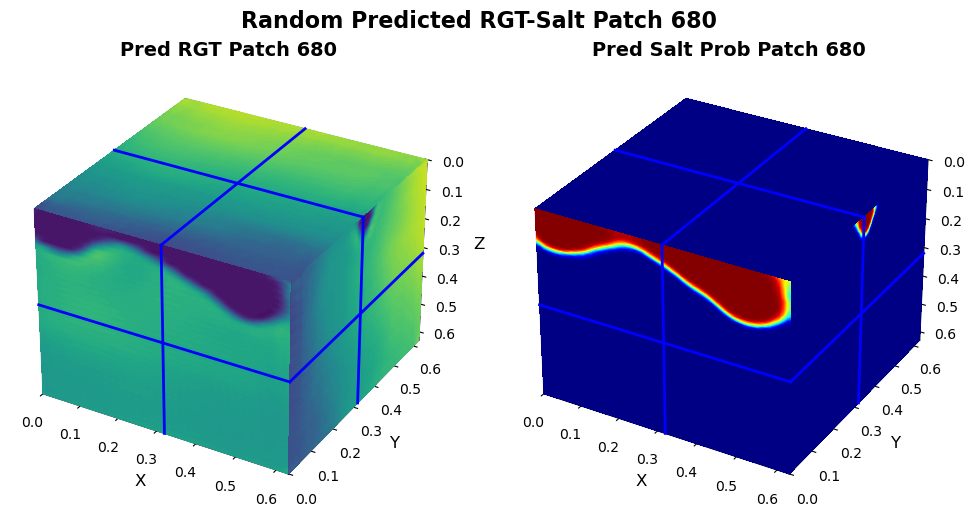

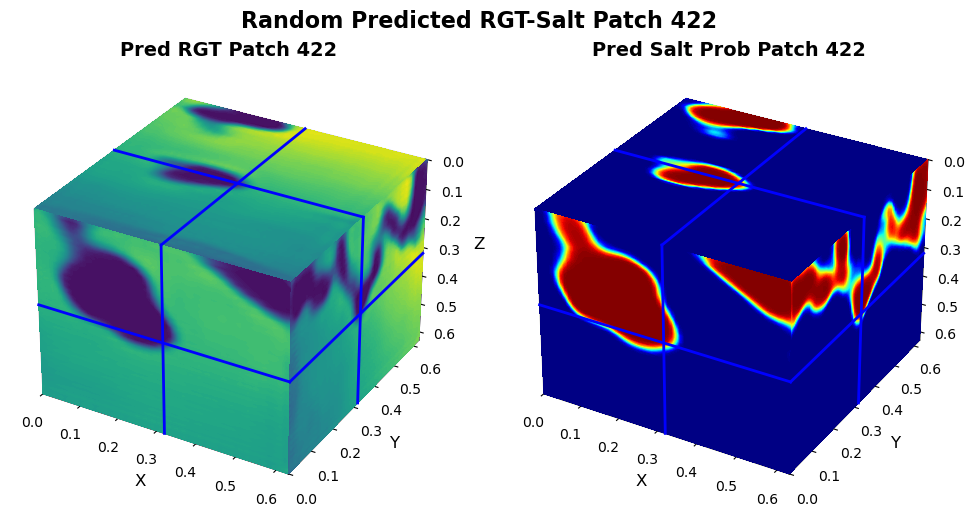

In [20]:
# =========================
# randomly show 2 predicted patches
# =========================
num_show = 2

np.random.seed(20260532)
idxs = np.random.choice(pred_rgt.shape[0], num_show, replace=False)

print("Patch indices:", idxs)

for i in idxs:
    rgt_patch_i = pred_rgt[i, 0, :, :, :]
    salt_patch_i = pred_lab[i, 0, :, :, :]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 5),
        subplot_kw={"projection": "3d"},
        constrained_layout=True
    )

    axes[0].set_title(f"Pred RGT Patch {i}", fontsize=14, fontweight="bold")
    plt.sca(axes[0])
    plot3d(
        rgt_patch_i,
        cmap="viridis",
        frames=[32, 32, 32],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

    axes[1].set_title(f"Pred Salt Prob Patch {i}", fontsize=14, fontweight="bold")
    plt.sca(axes[1])
    plot3d(
        salt_patch_i,
        cmap="jet",
        frames=[32, 32, 32],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

    plt.suptitle(f"Random Predicted RGT-Salt Patch {i}", fontsize=16, fontweight="bold")
    plt.show()

## Quantitative evaluation on the synthetic test volume

This step quantitatively evaluates the model performance on the unseen synthetic test volume for both tasks.

For **salt segmentation**, the predicted binary salt mask is compared with the ground-truth salt mask using:

- confusion matrix,
- accuracy,
- precision,
- recall,
- F1-score.

For **RGT prediction**, the predicted continuous RGT volume is compared with the ground-truth RGT volume using:

- mean squared error (MSE),
- root mean squared error (RMSE),
- mean absolute error (MAE),
- coefficient of determination ($R^2$).

These metrics provide complementary evaluation of the model: classification performance for salt segmentation and regression accuracy for RGT prediction.

In [21]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import numpy as np

# =========================
# Salt metrics
# =========================
y_true_salt = (syn_salt_test.reshape(-1) > 0.5).astype(np.uint8)
y_pred_salt = pred_salt_bin_rec.reshape(-1).astype(np.uint8)

print("===== Salt metrics =====")
print("Confusion matrix:")
print(confusion_matrix(y_true_salt, y_pred_salt))

print("Accuracy :", accuracy_score(y_true_salt, y_pred_salt))
print("Precision:", precision_score(y_true_salt, y_pred_salt, zero_division=0))
print("Recall   :", recall_score(y_true_salt, y_pred_salt, zero_division=0))
print("F1-score :", f1_score(y_true_salt, y_pred_salt, zero_division=0))


# =========================
# RGT metrics
# =========================
y_true_rgt = syn_rgt_test.reshape(-1).astype(np.float32)
y_pred_rgt = pred_rgt_vol.reshape(-1).astype(np.float32)

mse = mean_squared_error(y_true_rgt, y_pred_rgt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_rgt, y_pred_rgt)
r2 = r2_score(y_true_rgt, y_pred_rgt)

print("\n===== RGT metrics =====")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

===== Salt metrics =====
Confusion matrix:
[[713054   8611]
 [ 10455 152616]]
Accuracy : 0.9784500687210648
Precision: 0.9465908315604706
Recall   : 0.935886822304395
F1-score : 0.9412083947480405

===== RGT metrics =====
MSE : 0.007904642
RMSE: 0.088908054
MAE : 0.053883553
R2  : 0.8994942537466869


In [22]:
non_salt_mask = syn_salt_test.reshape(-1) < 0.5

y_true_rgt_ns = y_true_rgt[non_salt_mask]
y_pred_rgt_ns = y_pred_rgt[non_salt_mask]

print("\n===== RGT metrics / non-salt only =====")
print("MSE :", mean_squared_error(y_true_rgt_ns, y_pred_rgt_ns))
print("RMSE:", np.sqrt(mean_squared_error(y_true_rgt_ns, y_pred_rgt_ns)))
print("MAE :", mean_absolute_error(y_true_rgt_ns, y_pred_rgt_ns))
print("R2  :", r2_score(y_true_rgt_ns, y_pred_rgt_ns))


===== RGT metrics / non-salt only =====
MSE : 0.0055109602
RMSE: 0.07423584
MAE : 0.05044949
R2  : 0.9081519523609444


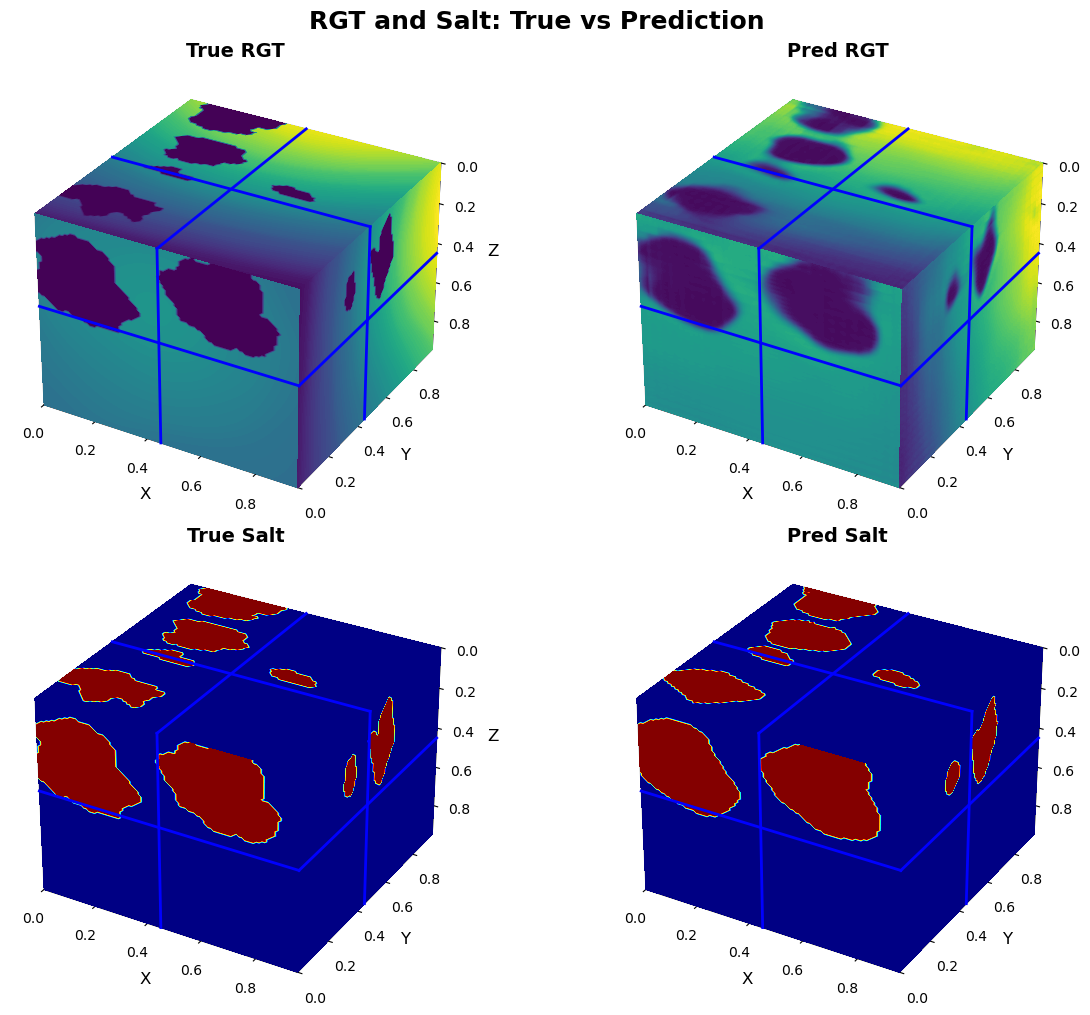

In [24]:
# =========================
# plot labels and predictions
# =========================
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    subplot_kw={"projection": "3d"},
    constrained_layout=True
)

plot_items = [
    (syn_rgt_test, "True RGT", "viridis"),
    (pred_rgt_vol, "Pred RGT", "viridis"),
    (syn_salt_test, "True Salt", "jet"),
    (pred_salt_bin_rec, "Pred Salt", "jet"),
]

for ax, (vol, title, cmap) in zip(axes.ravel(), plot_items):
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.sca(ax)

    plot3d(
        vol,
        cmap=cmap,
        frames=[45, 45, 45],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

plt.suptitle("RGT and Salt: True vs Prediction", fontsize=18, fontweight="bold")
plt.show()

## Load real F3 seismic data for synthetic-to-real salt segmentation transfer

This step prepares the real F3 Netherlands seismic dataset for transfer learning and salt-body segmentation.

The real seismic volume is loaded from:

`./Data/F3data/F3_data.mat`

and the corresponding salt label volume is loaded from:

`./Data/F3data/F3_label.mat`

Here:

- `real_data` contains the real 3D seismic volume,
- `real_salt` contains the manually interpreted salt labels.

After loading, both volumes are transposed using `(2, 1, 0)` to match the data orientation used by the synthetic GeoFWI3D volumes and the trained `SaltRGT3DNet` model.

This ensures that the real seismic data and salt labels are spatially aligned and ready for patch-based transfer learning or inference.

In [25]:
from scipy import io
import scipy
# =========================
# load real F3 data
# =========================
datas_all = scipy.io.loadmat("./Data/F3data/F3_data.mat")
real_data = datas_all["data"]

labels_all = scipy.io.loadmat("./Data/F3data/F3_label.mat")
real_salt = labels_all["label"]

print("real_data shape:", real_data.shape)
print("real_salt shape:", real_salt.shape)

real_data = np.transpose(real_data, (2,1,0))
real_salt = np.transpose(real_salt, (2,1,0))

print("real_data shape:", real_data.shape)
print("real_salt shape:", real_salt.shape)

real_data shape: (126, 400, 360)
real_salt shape: (126, 400, 360)
real_data shape: (360, 400, 126)
real_salt shape: (360, 400, 126)


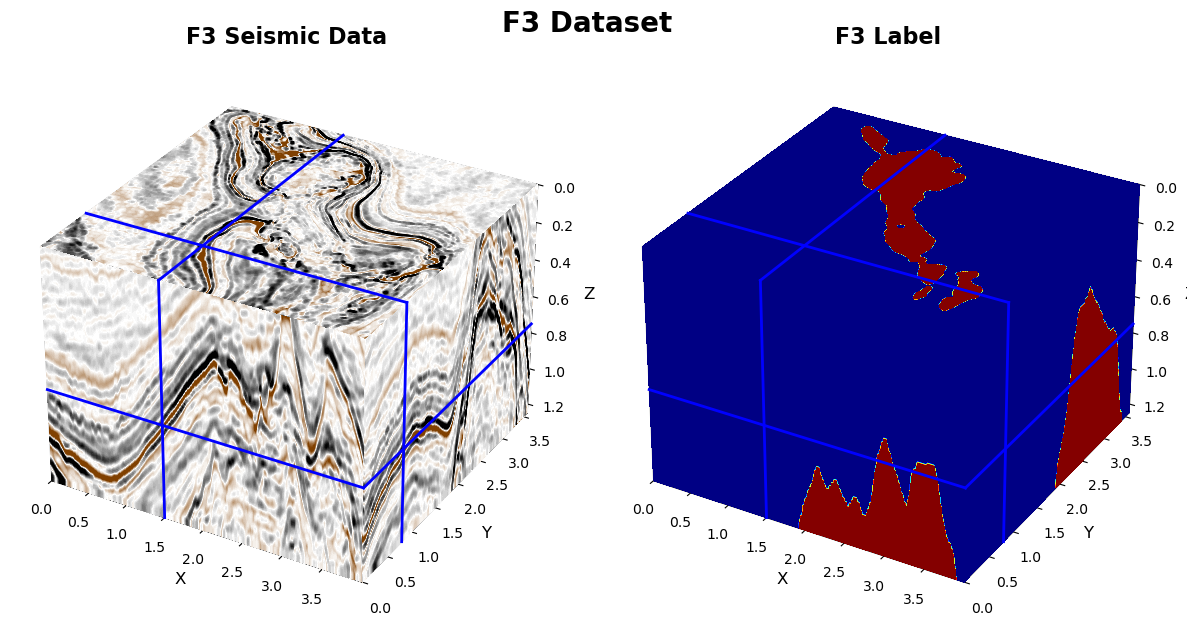

In [26]:
plot_f3_data_label(data=real_data,label=real_salt,
    suptitle="F3 Dataset",
)

## Prepare real F3 training patches

This step converts the real F3 seismic volume and salt labels into overlapping 3D patches for synthetic-to-real transfer learning.

The real seismic data and salt labels are divided into patches with size $64 \times 64 \times 64$.  
Sliding strides of $8 \times 16 \times 16$ are used to increase the number of training samples while preserving spatial continuity.

The extracted seismic patches are normalized by their maximum absolute amplitudes to reduce amplitude variations across different regions of the real seismic volume.

The salt labels are converted into binary masks:

- salt = 1,
- non-salt = 0.

Finally, a channel dimension is added to both seismic patches and salt-label patches to match the input/output format required by the 3D CNN model.

The resulting datasets are:

- `X_real`: real seismic input patches,
- `Y_real`: real salt-label target patches.

In [27]:
l1, l2, l3 = 64, 64, 64
s1, s2, s3 = 8, 16, 16

real_data_patches = patch3d_optimized(
    real_data, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3
)

real_salt_patches = patch3d_optimized(
    real_salt, l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3
)

real_data_patches = real_data_patches.reshape(-1, l1, l2, l3)
real_salt_patches = real_salt_patches.reshape(-1, l1, l2, l3)

# normalize seismic patches
for i in range(real_data_patches.shape[0]):
    tmp = np.abs(real_data_patches[i]).max()
    if tmp > 0:
        real_data_patches[i] = real_data_patches[i] / tmp

# binary salt label
real_salt_patches = (real_salt_patches > 0.5).astype(np.float32)

X_real = real_data_patches[:, np.newaxis, :, :, :]
Y_real = real_salt_patches[:, np.newaxis, :, :, :]

print("X_real:", X_real.shape)
print("Y_real:", Y_real.shape)

X_real: (4180, 1, 64, 64, 64)
Y_real: (4180, 1, 64, 64, 64)


Patch indices: [3857 2199]


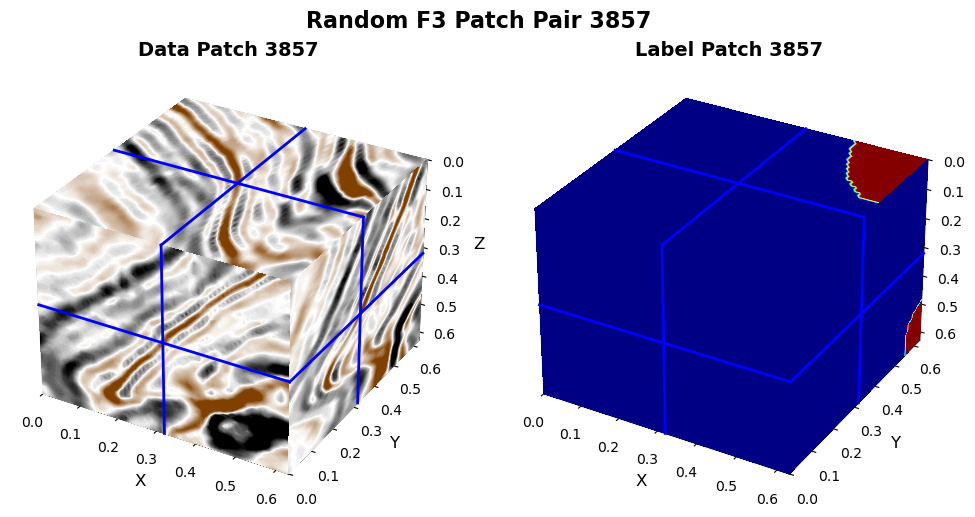

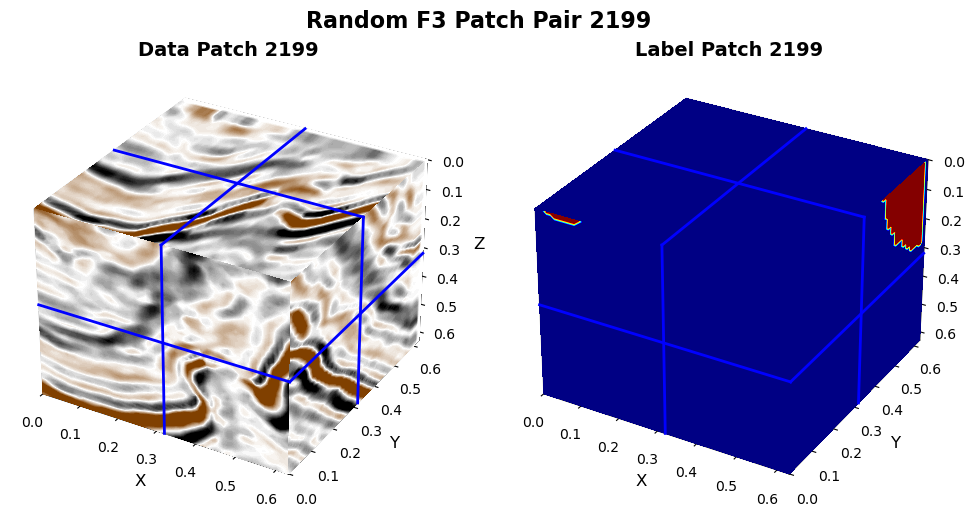

In [28]:
# =========================
# randomly show 2 patches
# =========================
num_show = 2

np.random.seed(2026059) 
idxs = np.random.choice(real_data_patches.shape[0], num_show, replace=False)

print("Patch indices:", idxs)

for i in idxs:
    data_patch_i = real_data_patches[i].reshape(l1, l2, l3)
    label_patch_i = real_salt_patches[i].reshape(l1, l2, l3)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 5),
        subplot_kw={'projection': '3d'},
        constrained_layout=True
    )

    axes[0].set_title(f"Data Patch {i}", fontsize=14, fontweight="bold")
    plt.sca(axes[0])
    plot3d(
        data_patch_i,
        cmap=cseis(),
        frames=[32, 32, 32],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

    axes[1].set_title(f"Label Patch {i}", fontsize=14, fontweight="bold")
    plt.sca(axes[1])
    plot3d(
        label_patch_i,
        cmap="jet",
        frames=[32, 32, 32],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

    plt.suptitle(f"Random F3 Patch Pair {i}", fontsize=16, fontweight="bold")
    plt.show()

## Reshape and normalize real F3 seismic patches

This step reshapes the extracted real F3 seismic and salt-label patches into standard 3D patch format:

- `real_data_patches`: real seismic patches with shape `(N, 64, 64, 64)`,
- `real_salt_patches`: real salt-label patches with shape `(N, 64, 64, 64)`.

Before normalization, the patch shapes are printed to confirm that the seismic patches and salt-label patches remain spatially paired.

Each real seismic patch is then normalized by its maximum absolute amplitude.  
This patch-wise normalization reduces local amplitude-scale differences and makes the real F3 data more consistent with the normalized synthetic training patches.

In [29]:
real_data_patches = real_data_patches.reshape(-1, l1, l2, l3)
real_salt_patches = real_salt_patches.reshape(-1, l1, l2, l3)

print("before norm:", real_data_patches.shape, real_salt_patches.shape)

# normalize each 3D seismic patch
for i in range(real_data_patches.shape[0]):
    tmp = np.abs(real_data_patches[i]).max()
    if tmp > 0:
        real_data_patches[i] = real_data_patches[i] / tmp

before norm: (4180, 64, 64, 64) (4180, 64, 64, 64)


## Split real F3 patches for transfer learning

This step splits the real F3 patches into training and testing subsets for salt-segmentation transfer learning.

Here, `test_size=0.9` means that only **10%** of the real F3 patches are used for fine-tuning, while the remaining **90%** are kept for testing.  
This setting simulates a limited-label real-data scenario.

The split is applied consistently to both:

- `real_data_patches`: real seismic input patches,
- `real_salt_patches`: real binary salt-label patches.

In [30]:
from sklearn.model_selection import train_test_split

Xtrain_real, Xtest_real, Ytrain_real, Ytest_real = train_test_split(
    real_data_patches,
    real_salt_patches,
    test_size=0.9,     
    random_state=42,
    shuffle=True
)

Xtrain_real, Xtest_real, Ytrain_real, Ytest_real = [
    arr[:, np.newaxis, :, :, :]
    for arr in [Xtrain_real, Xtest_real, Ytrain_real, Ytest_real]
]

print("Xtrain_real shape:", Xtrain_real.shape)
print("Xtest_real shape :", Xtest_real.shape)
print("Ytrain_real shape:", Ytrain_real.shape)
print("Ytest_real shape :", Ytest_real.shape)

Xtrain_real shape: (418, 1, 64, 64, 64)
Xtest_real shape : (3762, 1, 64, 64, 64)
Ytrain_real shape: (418, 1, 64, 64, 64)
Ytest_real shape : (3762, 1, 64, 64, 64)


## Fine-tune the pretrained synthetic model on real F3 salt labels

This step transfers the synthetic GeoFWI3D-trained model to the real F3 salt-segmentation task.

First, the pretrained RGT and Salt model is loaded from:

`model/best_model_rgt_salt.h5`

Since the real F3 dataset only provides salt labels, the model is converted into a single-output salt-segmentation model by keeping only the `outlab` output layer.

To preserve the synthetic pretraining knowledge, the early layers are frozen, while only the later bottleneck, salt decoder, and output layers are fine-tuned on the real F3 data.

The fine-tuned model is trained using:

- binary cross-entropy loss,
- accuracy as the validation metric,
- early stopping,
- learning-rate reduction,
- automatic saving of the best real data model.

The best fine-tuned model is saved as:

`model/best_real_salt_bottleneck_decoder.pth`

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# load pretrained synthetic model
# =========================
salt_model = SaltRGT3DNet(input_channels=1, D=2, layer=1, layers=1).to(device)

salt_model.load_state_dict(
    torch.load(
        "model/best_model_rgt_salt.pth",
        map_location=device,
        weights_only=True
    )
)

# =========================
# freeze encoder + RGT branch
# train bottleneck + salt decoder + outlab
# =========================
for name, param in salt_model.named_parameters():
    param.requires_grad = False

    if (
        name.startswith("bottleneck")
        or name.startswith("lab_decoder")
        or name.startswith("outlab")
    ):
        param.requires_grad = True

# =========================
# data loader
# =========================
train_dataset = TensorDataset(
    torch.from_numpy(Xtrain_real).float(),
    torch.from_numpy(Ytrain_real).float()
)

val_dataset = TensorDataset(
    torch.from_numpy(Xtest_real).float(),
    torch.from_numpy(Ytest_real).float()
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# =========================
# optimizer / loss
# =========================
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, salt_model.parameters()),
    lr=1e-3,
    eps=1e-7
)

criterion = nn.BCELoss()

# =========================
# fine-tune
# =========================
best_val_acc = 0.0
patience = 10
wait = 0

for epoch in range(100):
    salt_model.train()
    train_loss = 0.0
    train_acc = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/100"):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        _, pred_salt = salt_model(x)

        loss = criterion(pred_salt, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred_bin = (pred_salt > 0.5).float()
        acc = (pred_bin == y).float().mean()
        train_acc += acc.item()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # =========================
    # validation
    # =========================
    salt_model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            _, pred_salt = salt_model(x)

            loss = criterion(pred_salt, y)
            val_loss += loss.item()

            pred_bin = (pred_salt > 0.5).float()
            acc = (pred_bin == y).float().mean()
            val_acc += acc.item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train_loss={train_loss:.6f} | "
        f"train_acc={train_acc:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"val_acc={val_acc:.6f}"
    )

    # =========================
    # save best model
    # =========================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0

        torch.save(
            salt_model.state_dict(),
            "model/best_real_salt_bottleneck_decoder.pth"
        )

        print("Saved best real salt model.")
    else:
        wait += 1

    # =========================
    # simple early stopping
    # =========================
    if wait >= patience:
        print("Early stopping.")
        break

Epoch 1/100: 100%|██████████| 105/105 [00:05<00:00, 20.22it/s]


Epoch 001 | train_loss=0.430270 | train_acc=0.843279 | val_loss=0.239654 | val_acc=0.873261
Saved best real salt model.


Epoch 2/100: 100%|██████████| 105/105 [00:04<00:00, 21.46it/s]


Epoch 002 | train_loss=0.259246 | train_acc=0.858429 | val_loss=0.215315 | val_acc=0.895874
Saved best real salt model.


Epoch 3/100: 100%|██████████| 105/105 [00:04<00:00, 21.43it/s]


...

Epoch 069 | train_loss=0.017958 | train_acc=0.992876 | val_loss=0.026357 | val_acc=0.989995


Epoch 70/100: 100%|██████████| 105/105 [00:04<00:00, 21.26it/s]


Epoch 070 | train_loss=0.017952 | train_acc=0.992910 | val_loss=0.026467 | val_acc=0.989949


Epoch 71/100: 100%|██████████| 105/105 [00:04<00:00, 21.20it/s]


Epoch 071 | train_loss=0.019011 | train_acc=0.992553 | val_loss=0.030129 | val_acc=0.988934
Early stopping.


## Load the fine-tuned real F3 salt segmentation model

This step prepares the full set of real F3 seismic patches for inference.

A channel dimension is added to all real seismic patches to form:

`X_real_all`

Then, the fine-tuned salt-segmentation model is loaded from:

`model/best_real_salt_bottleneck_decoder.pth`

This model will be used to predict salt probabilities for all real F3 patches and reconstruct the full 3D salt-probability volume.

In [35]:
import torch

# =========================
# prepare input
# =========================
X_real_all = real_data_patches[:, np.newaxis, :, :, :]

# =========================
# load fine-tuned PyTorch model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

salt_model = SaltRGT3DNet(
    input_channels=1,
    D=2,
    layer=1,
    layers=1
).to(device)

salt_model.load_state_dict(
    torch.load(
        "model/best_real_salt_bottleneck_decoder.pth",
        map_location=device,
        weights_only=True
    )
)

# salt_model.eval()

<All keys matched successfully>

## Predict and reconstruct the full real F3 Salt volume

This step applies the fine-tuned real F3 salt-segmentation model to all extracted real seismic patches.

First, the input patch array is checked and reshaped if necessary to ensure that it has the required 3D CNN format:

`(N, 1, 64, 64, 64)`

The model then predicts salt probabilities for all real F3 patches.  
After prediction, the channel dimension is removed, and the patch-wise salt probability predictions are reconstructed back into the original full 3D F3 volume using `patch3d_inv_optimized`.

Finally, the reconstructed salt-probability volume is converted into a binary salt mask using a threshold of 0.5:

$\mathrm{salt}=1 \quad \text{if} \quad P_{\mathrm{salt}}>0.5$.

The final outputs are:

- `pred_lab_prob_rec`: reconstructed 3D salt probability volume,
- `pred_lab_bin_rec`: reconstructed binary 3D salt segmentation volume.

In [36]:
import torch
import numpy as np
from tqdm import tqdm

# =========================
# prepare input
# PyTorch format: (N, 1, 64, 64, 64)
# =========================
if real_data_patches.ndim == 4:
    X_real_all = real_data_patches[:, np.newaxis, :, :, :]
else:
    X_real_all = real_data_patches

print("input shape:", X_real_all.shape)

# =========================
# prediction
# =========================
X_real_tensor = torch.from_numpy(X_real_all).float()

pred_lab_list = []
batch_size = 4

salt_model.eval()

with torch.no_grad():
    for i in tqdm(range(0, X_real_tensor.shape[0], batch_size)):
        x_batch = X_real_tensor[i:i + batch_size].to(device)

        _, pred_lab_batch = salt_model(x_batch)

        pred_lab_list.append(pred_lab_batch.cpu().numpy())

pred_lab = np.concatenate(pred_lab_list, axis=0)

print("pred_lab shape:", pred_lab.shape)

# =========================
# remove channel dimension
# Output: (N, 1, 64, 64, 64)
# =========================
pred_lab_prob = pred_lab[:, 0, :, :, :]

# =========================
# reconstruct pred_lab probability
# =========================
pred_lab_prob_rec = patch3d_inv_optimized(
    pred_lab_prob.reshape(pred_lab_prob.shape[0], -1),
    n1=real_data.shape[0],
    n2=real_data.shape[1],
    n3=real_data.shape[2],
    l1=l1, l2=l2, l3=l3,
    s1=s1, s2=s2, s3=s3
)

# =========================
# threshold after reconstruction
# =========================
pred_lab_bin_rec = (pred_lab_prob_rec > 0.5).astype(np.uint8)

print("pred_lab_prob_rec shape:", pred_lab_prob_rec.shape)
print("pred_lab_bin_rec shape :", pred_lab_bin_rec.shape)

input shape: (4180, 1, 64, 64, 64)


100%|██████████| 1045/1045 [00:19<00:00, 53.75it/s]


pred_lab shape: (4180, 1, 64, 64, 64)
pred_lab_prob_rec shape: (360, 400, 126)
pred_lab_bin_rec shape : (360, 400, 126)


## Visualize real F3 salt segmentation results

This step qualitatively compares the real F3 salt label with the predicted salt-segmentation results.

Three 3D views are displayed side by side:

- **True Salt**: the reference salt label from the F3 dataset,
- **Pred Salt Probability**: the reconstructed salt-probability volume predicted by the fine-tuned model,
- **Pred Salt Binary**: the final binary salt mask after applying the 0.5 threshold.

The visualization helps assess whether the transferred model can correctly identify the main salt-body geometry in the real F3 seismic volume.

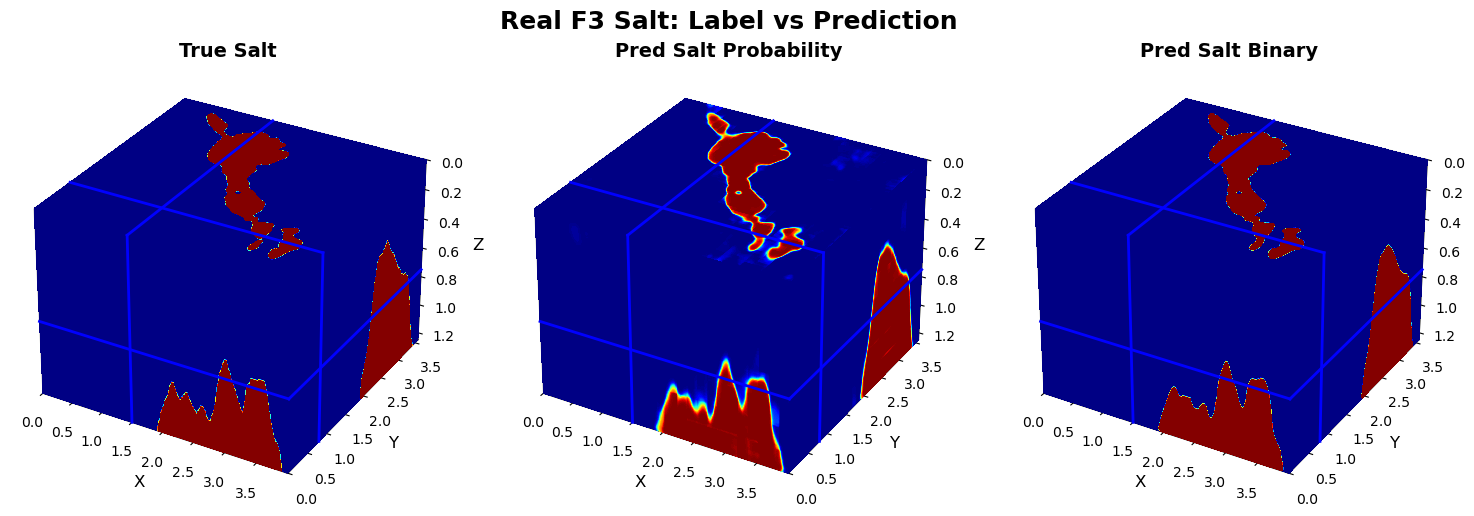

In [37]:
# =========================
# compare true salt and predicted salt
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    subplot_kw={"projection": "3d"},
    constrained_layout=True
)

plot_items = [
    (real_salt, "True Salt", "jet"),
    (pred_lab_prob_rec, "Pred Salt Probability", "jet"),
    (pred_lab_bin_rec, "Pred Salt Binary", "jet"),
]

for ax, (vol, title, cmap) in zip(axes, plot_items):
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.sca(ax)

    plot3d(
        vol.T,
        cmap=cmap,
        frames=[75, 150, 80],
        ifnewfig=False,
        showf=False,
        close=False,
        ifinside=False,
    )

plt.suptitle("Real F3 Salt: Label vs Prediction", fontsize=18, fontweight="bold")
plt.show()

## Quantitative evaluation on the real F3 salt volume

This step evaluates the fine-tuned model on the full real F3 salt segmentation result.

The true salt label and predicted binary salt mask are first flattened into 1D arrays.  
Then, voxel-wise segmentation performance is measured using:

- confusion matrix,
- accuracy,
- precision,
- recall,
- F1-score.

These metrics quantify how well the synthetic-to-real transferred model identifies salt and non-salt regions in the real F3 seismic volume.

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# =========================
# flatten true / prediction
# =========================
y_true = (real_salt.reshape(-1) > 0.5).astype(np.uint8)
y_pred = pred_lab_bin_rec.reshape(-1).astype(np.uint8)

# =========================
# metrics
# =========================
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Confusion matrix:")
print(cm)

print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1-score :", f1)

Confusion matrix:
[[15891498    54533]
 [   41628  2156341]]
Accuracy : 0.9947001212522046
Precision: 0.9753341891034948
Recall   : 0.981060697398371
F1-score : 0.9781890623004721
